In [95]:

# Traffic Sign Classification Project

from traitlets import This


#This notebook loads the dataset, trains multiple CNN models, and evaluates them on the hold-out test set.

import os
import cv2
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    RandomRotation,
    RandomZoom,
    RandomTranslation,
    RandomContrast,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Dense,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [96]:
# -----------------------------
# Settings
# -----------------------------
IMG_SIZE = 128

classes = [
    "stop",
    "speed_limit",
    "no_entry",
    "pedestrian",
    "turn_left",
    "turn_right",
]

class_to_index = {name: idx for idx, name in enumerate(classes)}

dataset_path = Path("../dataset")
augmented_path = Path("../augmented")
external_path = Path("../external")

In [97]:
# -----------------------------
# Data loading
# -----------------------------
def load_images_from_folder(base_path, class_names):
    images = []
    labels = []

    for class_name in class_names:
        class_folder = base_path / class_name
        class_index = class_to_index[class_name]

        if not class_folder.exists():
            print(f"WARNING: Folder not found: {class_folder}")
            continue

        for filename in os.listdir(class_folder):
            filepath = class_folder / filename
            image = cv2.imread(str(filepath))

            if image is None:
                continue

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = image.astype(np.float32) / 255.0

            images.append(image)
            labels.append(class_index)

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

X_original, y_original = load_images_from_folder(dataset_path, classes)
X_augmented, y_augmented = load_images_from_folder(augmented_path, classes)
X_external, y_external = load_images_from_folder(external_path, classes)

X_train = np.concatenate([X_original, X_augmented], axis=0)
y_train = np.concatenate([y_original, y_augmented], axis=0)

X_val, X_test, y_val, y_test = train_test_split(
    X_external,
    y_external,
    test_size=0.30,
    random_state=42,
    stratify=y_external,
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Train class counts:", np.bincount(y_train, minlength=len(classes)))
print("Validation class counts:", np.bincount(y_val, minlength=len(classes)))
print("Test class counts:", np.bincount(y_test, minlength=len(classes)))

Training set: (569, 128, 128, 3) (569,)
Validation set: (439, 128, 128, 3) (439,)
Test set: (189, 128, 128, 3) (189,)
Train class counts: [95 94 95 95 95 95]
Validation class counts: [ 52  58  66 205  31  27]
Test class counts: [22 25 28 89 14 11]


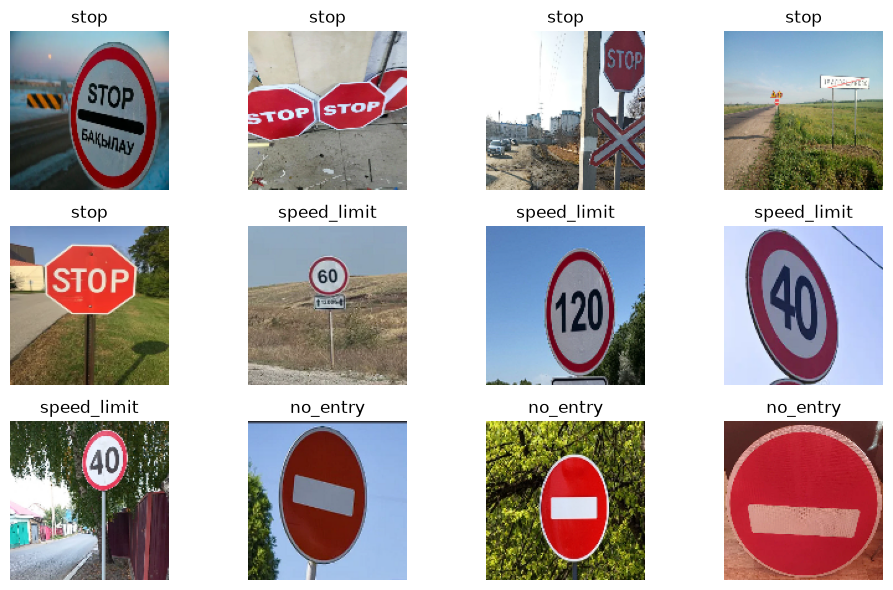

In [98]:
# -----------------------------
# Preview samples
# -----------------------------
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [99]:
# -----------------------------
# Baseline CNN
# -----------------------------
baseline_model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(len(classes), activation="softmax"),
])

baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.5378 - loss: 1.1149 - val_accuracy: 0.2369 - val_loss: 3.4734
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9350 - loss: 0.2454 - val_accuracy: 0.2392 - val_loss: 5.3892
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9736 - loss: 0.0953 - val_accuracy: 0.2278 - val_loss: 6.0631
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9701 - loss: 0.0874 - val_accuracy: 0.2164 - val_loss: 8.3637
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9754 - loss: 0.0864 - val_accuracy: 0.2187 - val_loss: 7.8650
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9772 - loss: 0.1114 - val_accuracy: 0.2779 - val_loss: 6.3261
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9982 - loss: 0.0163 - val_accuracy: 0.2733 - val_loss: 6.3544
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.3394 - v

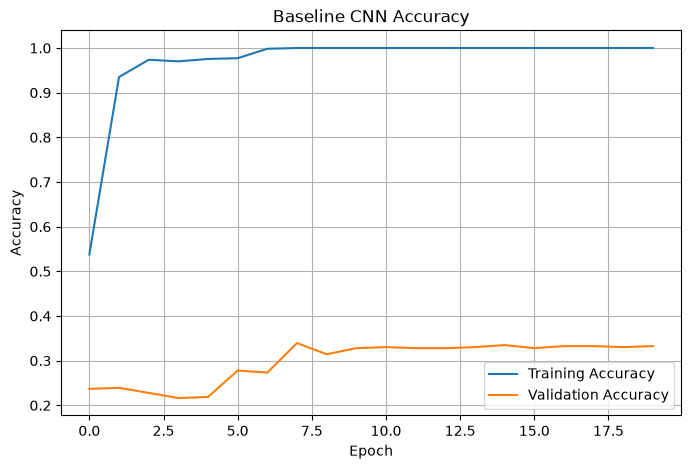

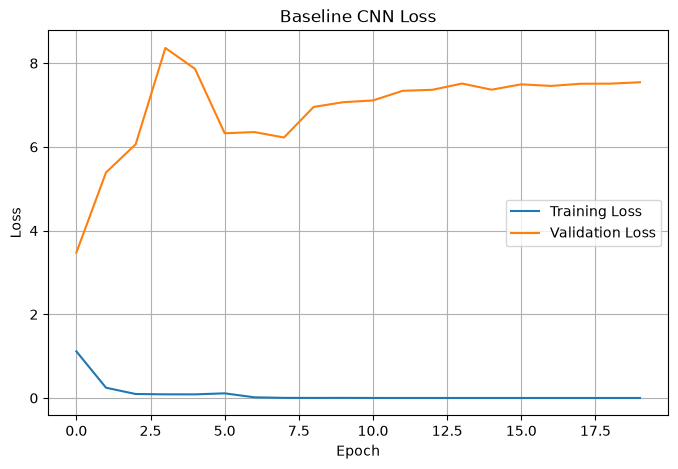

In [100]:
history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1,
)

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
# -----------------------------
# Improved CNN
# -----------------------------
data_augmentation = Sequential([
    RandomRotation(0.03),
    RandomZoom(0.10),
    RandomTranslation(0.08, 0.08),
    RandomContrast(0.10),
], name="data_augmentation")

improved_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.15),

    Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding="same", activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu", kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.40),
    Dense(len(classes), activation="softmax"),
])

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

improved_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           77

 Total params: 424,518 (1.62 MB)

 Trainable params: 423,302 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [102]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 334ms/step - accuracy: 0.5308 - loss: 1.3425 - val_accuracy: 0.1321 - val_loss: 1.7795 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.7469 - loss: 0.7438 - val_accuracy: 0.1321 - val_loss: 1.9409 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8243 - loss: 0.5068
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.8243 - loss: 0.5068 - val_accuracy: 0.1321 - val_loss: 2.8777 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.9086 - loss: 0.3295 - val_accuracy: 0.1321 - val_loss: 3.6769 - learning_rate: 5.0000e-04
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9385 - loss: 0.2514
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.9385 - loss: 0.2514 

In [103]:
# -----------------------------
# Transfer learning model
# -----------------------------
data_augmentation_tl = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.08),
], name="traffic_sign_augmentation")

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation_tl(inputs)
x = layers.Rescaling(255.0)(x)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(len(classes), activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs)

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ traffic_sign_augmentation       │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [104]:
early_stopping_tl = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

history_transfer = transfer_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping_tl, reduce_lr_tl],
    verbose=1,
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.7540 - loss: 0.8043 - val_accuracy: 0.2437 - val_loss: 2.1473 - learning_rate: 5.0000e-04
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.9982 - loss: 0.0869 - val_accuracy: 0.3462 - val_loss: 2.1336 - learning_rate: 5.0000e-04
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 1.0000 - loss: 0.0400 - val_accuracy: 0.2961 - val_loss: 2.3123 - learning_rate: 5.0000e-04
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.0347
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 1.0000 - loss: 0.0347 - val_accuracy: 0.2802 - val_loss: 2.4623 - learning_rate: 5.0000e-04
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 1.0000 - loss: 0.0319 - val_accuracy: 0.2870 - val_loss: 2.4337 - learning_rate: 2.5000e-04
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 

In [105]:
# -----------------------------
# Fine tuning transfer model
# -----------------------------
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = transfer_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_tl, reduce_lr_tl],
    verbose=1,
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 1.0000 - loss: 0.0397 - val_accuracy: 0.2870 - val_loss: 2.5852 - learning_rate: 1.0000e-05
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 0.3189 - val_loss: 2.5634 - learning_rate: 1.0000e-05
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 0.2984 - val_loss: 2.6928 - learning_rate: 1.0000e-05
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.0244
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.2825 - val_loss: 2.8411 - learning_rate: 1.0000e-05
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 1.0000 - loss: 0.0250 - val_accuracy: 0.2802 - val_loss: 2.8480 - learning_rate: 5.0000e-06
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 

In [106]:
# -----------------------------
# Evaluation helper
# -----------------------------
def evaluate_model(model, x_data, y_true, model_name):
    y_pred = np.argmax(model.predict(x_data, verbose=0), axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print(classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0,
    ))

    return y_pred

In [107]:
# -----------------------------
# Baseline evaluation
# -----------------------------
y_pred_baseline = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline CNN"
)

print("\nBaseline confusion matrix:")
print(confusion_matrix(y_test, y_pred_baseline))


Baseline CNN
------------
Accuracy:  0.3915
Precision: 0.4970
Recall:    0.3915
F1-score:  0.3891
              precision    recall  f1-score   support

        stop       0.41      0.64      0.50        22
 speed_limit       0.25      0.76      0.37        25
    no_entry       0.00      0.00      0.00        28
  pedestrian       0.72      0.37      0.49        89
   turn_left       0.80      0.29      0.42        14
  turn_right       0.33      0.36      0.35        11

    accuracy                           0.39       189
   macro avg       0.42      0.40      0.36       189
weighted avg       0.50      0.39      0.39       189


Baseline confusion matrix:
[[14  3  3  2  0  0]
 [ 2 19  4  0  0  0]
 [ 9 17  0  1  0  1]
 [ 8 35  8 33  0  5]
 [ 1  2  0  5  4  2]
 [ 0  1  0  5  1  4]]


In [108]:
# -----------------------------
# Improved evaluation
# -----------------------------
y_pred_improved = evaluate_model(
    improved_model,
    X_test,
    y_test,
    "Improved CNN"
)

print("\nImproved confusion matrix:")
print(confusion_matrix(y_test, y_pred_improved))


Improved CNN
------------
Accuracy:  0.1323
Precision: 0.0179
Recall:    0.1323
F1-score:  0.0315
              precision    recall  f1-score   support

        stop       0.00      0.00      0.00        22
 speed_limit       0.14      1.00      0.24        25
    no_entry       0.00      0.00      0.00        28
  pedestrian       0.00      0.00      0.00        89
   turn_left       0.00      0.00      0.00        14
  turn_right       0.00      0.00      0.00        11

    accuracy                           0.13       189
   macro avg       0.02      0.17      0.04       189
weighted avg       0.02      0.13      0.03       189


Improved confusion matrix:
[[ 0 22  0  0  0  0]
 [ 0 25  0  0  0  0]
 [ 0 28  0  0  0  0]
 [ 0 88  1  0  0  0]
 [ 0 14  0  0  0  0]
 [ 0  8  3  0  0  0]]


In [109]:
# -----------------------------
# Transfer evaluation
# -----------------------------
y_pred_transfer = evaluate_model(
    transfer_model,
    X_test,
    y_test,
    "Transfer Learning CNN"
)

print("\nTransfer confusion matrix:")
print(confusion_matrix(y_test, y_pred_transfer))


Transfer Learning CNN
---------------------
Accuracy:  0.3122
Precision: 0.4441
Recall:    0.3122
F1-score:  0.3221
              precision    recall  f1-score   support

        stop       0.19      0.73      0.30        22
 speed_limit       0.00      0.00      0.00        25
    no_entry       0.00      0.00      0.00        28
  pedestrian       0.79      0.37      0.50        89
   turn_left       0.67      0.57      0.62        14
  turn_right       0.04      0.18      0.07        11

    accuracy                           0.31       189
   macro avg       0.28      0.31      0.25       189
weighted avg       0.44      0.31      0.32       189


Transfer confusion matrix:
[[16  2  1  1  1  1]
 [22  0  0  1  0  2]
 [12  0  0  4  0 12]
 [26  2  0 33  0 28]
 [ 4  0  0  1  8  1]
 [ 4  0  0  2  3  2]]


In [110]:
# -----------------------------
# Optional final baseline
# -----------------------------
if "final_baseline_model" in globals():
    y_pred_final = evaluate_model(
        final_baseline_model,
        X_test,
        y_test,
        "Final Baseline CNN"
    )
    print("\nFinal baseline confusion matrix:")
    print(confusion_matrix(y_test, y_pred_final))
else:
    print("No final_baseline_model found in memory. Skip this cell if you do not need it.")


Final Baseline CNN
------------------
Accuracy:  0.3492
Precision: 0.4399
Recall:    0.3492
F1-score:  0.3728
              precision    recall  f1-score   support

        stop       0.32      0.55      0.40        22
 speed_limit       0.07      0.16      0.09        25
    no_entry       0.00      0.00      0.00        28
  pedestrian       0.69      0.48      0.57        89
   turn_left       0.60      0.21      0.32        14
  turn_right       0.40      0.36      0.38        11

    accuracy                           0.35       189
   macro avg       0.35      0.29      0.29       189
weighted avg       0.44      0.35      0.37       189


Final baseline confusion matrix:
[[12  5  4  1  0  0]
 [12  4  4  5  0  0]
 [ 6 16  0  6  0  0]
 [ 5 31  6 43  1  3]
 [ 3  1  0  4  3  3]
 [ 0  3  0  3  1  4]]


In [111]:
evaluate_model(transfer_model, X_original, y_original, "Transfer on OWN photos")
evaluate_model(transfer_model, X_external, y_external, "Transfer on EXTERNAL photos")


Transfer on OWN photos
----------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
              precision    recall  f1-score   support

        stop       1.00      1.00      1.00         5
 speed_limit       1.00      1.00      1.00         4
    no_entry       1.00      1.00      1.00         5
  pedestrian       1.00      1.00      1.00         5
   turn_left       1.00      1.00      1.00         5
  turn_right       1.00      1.00      1.00         5

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29


Transfer on EXTERNAL photos
---------------------------
Accuracy:  0.3169
Precision: 0.4502
Recall:    0.3169
F1-score:  0.3322
              precision    recall  f1-score   support

        stop       0.19      0.66      0.30        74
 speed_limit       0.12      0.02      0.04        83
    no_entry       0.00      0.00      0.00   

array([5, 0, 0, 0, 5, 5, 3, 0, 0, 0, 0, 0, 0, 5, 2, 3, 0, 1, 1, 0, 5, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 4, 1, 0, 3, 0, 3, 0, 2, 5, 0, 0, 0, 0,
       5, 3, 0, 0, 3, 0, 5, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0,
       0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 0, 0, 5, 0, 5, 1, 1,
       0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 5, 5, 5, 0, 5, 0, 0, 5, 0, 0, 0,
       0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 5, 5, 5,
       0, 0, 0, 0, 5, 3, 5, 5, 0, 5, 3, 5, 0, 0, 5, 5, 5, 5, 5, 5, 0, 5,
       3, 3, 5, 0, 5, 5, 5, 0, 0, 0, 0, 0, 5, 5, 5, 3, 0, 3, 0, 3, 5, 5,
       5, 0, 0, 3, 0, 5, 0, 0, 0, 5, 0, 0, 3, 0, 3, 5, 0, 0, 0, 0, 5, 0,
       0, 0, 0, 0, 0, 0, 5, 5, 0, 0, 0, 5, 0, 3, 3, 0, 0, 0, 1, 0, 3, 0,
       5, 0, 5, 0, 5, 5, 5, 5, 5, 3, 3, 3, 5, 3, 3, 3, 3, 5, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 5, 0, 5, 5, 5, 5, 5, 0, 5, 5, 5, 5, 5, 5,